In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos para ficarem mais bonitos e profissionais
sns.set_theme(style="whitegrid")
# Carregando a NOSSA base limpa do projeto anterior
# Substitua pelo nome correto do seu ficheiro limpo!
df = pd.read_csv('/content/drive/MyDrive/Ciência de Dados - EBAC/Projeto Telecon/Colab Notebooks/telecom_dados_limpos.csv', sep=';')
# Exibir as 5 primeiras linhas para garantir que os dados vieram certinhos
display(df.head())

,id_cliente,genero,idoso,casado,dependentes,tempo_como_cliente,servico_internet,servico_seguranca,suporte_tecnico,streaming_tv,tipo_contrato,metodo_pagamento,pagamento_mensal,total_pago,churn
0,7590-VHVEG,Female,0,Yes,No,1,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,No
4,9237-HQITU,Male,0,No,No,2,Fiber optic,No,No,No,Month-to-month,Electronic check,71.45,151.65,Yes


In [5]:
# Gerando as estatísticas descritivas das variáveis numéricas
resumo_estatistico = df.describe()
display(resumo_estatistico)

,idoso,tempo_como_cliente,pagamento_mensal,total_pago
count,2495.000000,2495.000000,2495.000000,2495.000000
mean,0.161122,32.354309,66.356894,2292.625812
std,0.367717,24.634007,28.013627,2266.888527
min,0.000000,0.000000,18.400000,18.800000
25%,0.000000,8.000000,45.550000,402.175000
50%,0.000000,29.000000,71.450000,1404.650000
75%,0.000000,56.000000,87.375000,3874.750000
max,1.000000,72.000000,118.650000,8564.750000



*A empresa possui clientes recém-adquiridos (0 meses) e uma forte base de retenção, com clientes que permanecem até 72 meses (6 anos). O facto de o máximo ser exatamente 72 sugere que a empresa pode ter pacotes de fidelização com prazos fixos até esse limite ou que o histórico de dados foi cortado aos 6 anos*

*Existe uma grande diferença entre o plano mais barato ($18.40) e o mais caro($118.65). Como a média ($66.35) está abaixo do meio termo desses valores, concluímos que a base de clientes está massivamente concentrada nos pacotes básicos e intermediários, havendo uma minoria a pagar pelos serviços premium.*




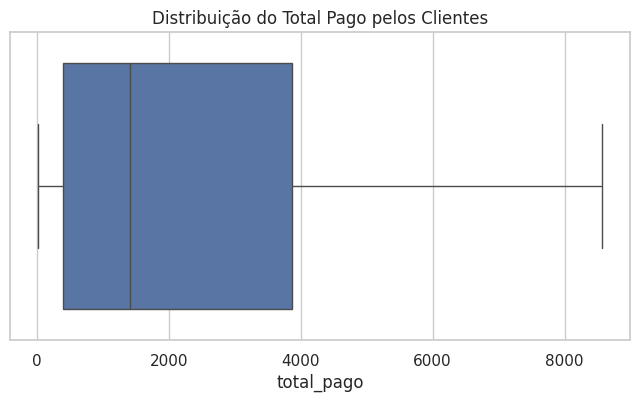

In [6]:
# Gráfico Boxplot
plt.figure(figsize= (8, 4))
sns.boxplot(x=df['total_pago'])
plt.title('Distribuição do Total Pago pelos Clientes')
plt.show()

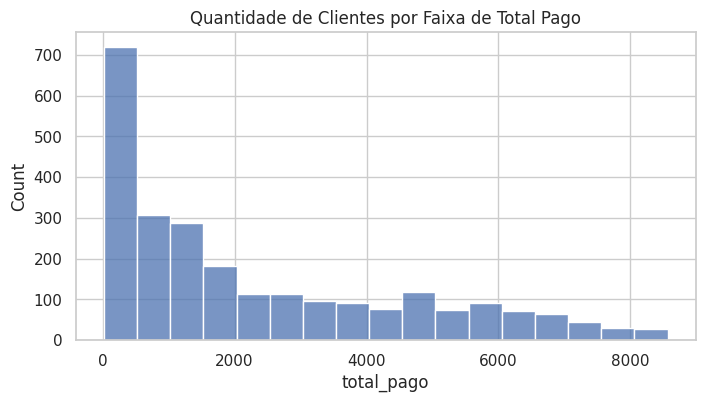

In [8]:
# Gráfico Histograma
plt.figure(figsize=(8,4))
sns.histplot(df['total_pago'])
plt.title('Quantidade de Clientes por Faixa de Total Pago')
plt.show()

*Apesar da diferença entre a média e o valor máximo sugerir a presença de outliers na variável 'total_pago', a visualização através do Boxplot não identificou valores atípicos (pontos isolados fora dos limites). O Histograma mostra uma distribuição assimétrica à direita (cauda longa), o que é natural no modelo de negócio de telecomunicações: uma grande concentração de clientes com baixo valor total (planos básicos ou recém-adquiridos) e uma curva contínua decrescente de clientes mais antigos que acumularam valores altos ao longo do tempo (até 72 meses). Portanto, não existem outliers a serem tratados nesta variável*

/tmp/ipykernel_1882/3605162922.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_1882/3605162922.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='tipo_contrato', data=df, ax=axes[1], palette='viridis')
/tmp/ipykernel_1882/3605162922.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='metodo_pagamento', data=df, ax=axes[2], palette='pastel')


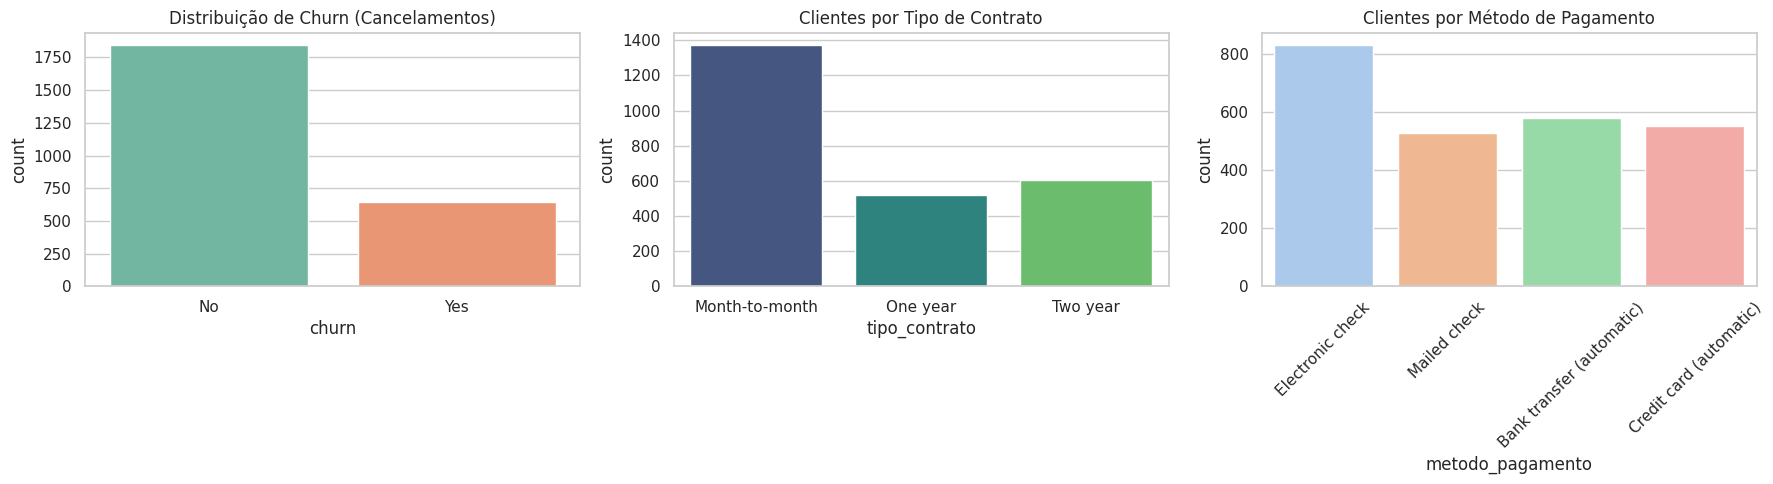

In [9]:
# Criando uma figura com 3 espaços (1 linha, 3 colunas)
fig, axes = plt.subplots(1,3, figsize=(18,5))
# Gráfico 1: A variável Alvo (Churn)
sns.countplot(x='churn', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribuição de Churn (Cancelamentos)')
# Gráfico 2: Tipo de Contrato
sns.countplot(x='tipo_contrato', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Clientes por Tipo de Contrato')
# Gráfico 3: Método de Pagamento
sns.countplot(x='metodo_pagamento', data=df, ax=axes[2], palette='pastel')
# Virando o texto do eixo X para não encavalar
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title('Clientes por Método de Pagamento')

plt.tight_layout()
plt.show()

*A análise do gráfico de barras revela que a variável alvo ('churn') está fortemente desbalanceada, com a classe majoritária ('No') representando a grande maioria da base em comparação com a classe minoritária ('Yes'). O impacto disto em projetos de Machine Learning é o viés algorítmico: modelos treinados nesta base tendem a 'decorar' a classe majoritária, apresentando uma falsa alta precisão geral, mas falhando miseravelmente em prever os clientes que realmente vão cancelar.*

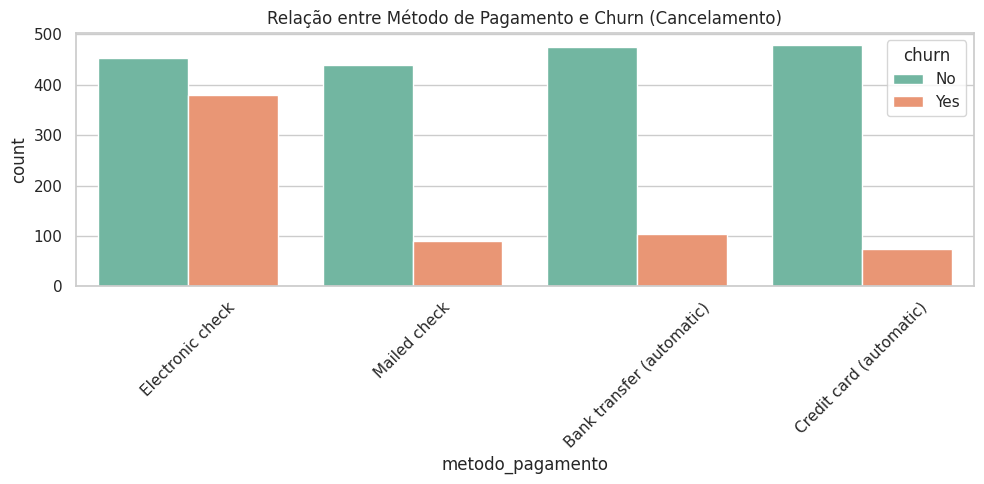

In [10]:
plt.figure(figsize=(10,5))
# O pulo do gato aqui é o "hue='churn'". Ele divide cada método de pagamento em duas barras: os que ficaram e os que saíram.
sns.countplot(data=df, x='metodo_pagamento', hue='churn', palette='Set2')

plt.title('Relação entre Método de Pagamento e Churn (Cancelamento)')
plt.xticks(rotation=45) # Rotaciona os nomes para caberem bonitinhos
plt.tight_layout()
plt.show()

*2. Método de Pagamento (metodo_pagamento vs churn)
Análise Estatística: O método Electronic check destaca-se negativamente como o principal canal associado ao cancelamento, registando uma taxa de churn de 45,55%, enquanto formas automáticas (como cartão de crédito e transferência bancária) mantêm taxas de retenção muito superiores.**

*Insight Estratégico: Há uma clara fricção ou falta de compromisso associada ao uso do Electronic check. A empresa deve implementar incentivos financeiros (cashback ou descontos na fatura) para encorajar os clientes a migrarem para meios de pagamento automáticos, que comprovadamente retêm mais clientes.**

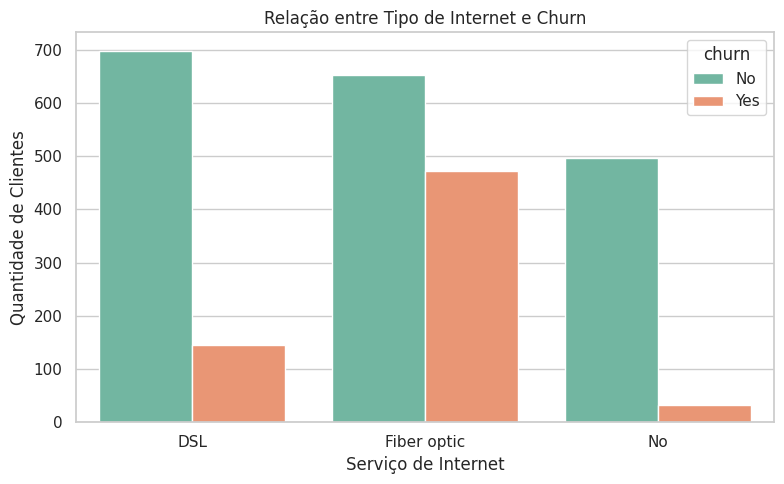

churn                No    Yes
servico_internet              
DSL               82.80  17.20
Fiber optic       58.01  41.99
No                93.94   6.06


In [12]:
plt.figure(figsize=(8,5))
# Cruzando o tipo de internet com o churn dividindo pelas cores (hue)
sns.countplot(data=df, x='servico_internet', hue='churn', palette='Set2')

plt.title('Relação entre Tipo de Internet e Churn')
plt.xlabel('Serviço de Internet')
plt.ylabel('Quantidade de Clientes')
plt.tight_layout()
plt.show()
# Calculando os percentuais exatos para apoiar o seu insight
crosstab = pd.crosstab(df['servico_internet'], df['churn'], normalize='index') * 100
print(crosstab.round(2))

*3. Tipo de Serviço de Internet (servico_internet vs churn)
Análise Estatística: Contrariando a lógica de que o produto mais moderno seria o mais estável, os clientes de Fibra Óptica (Fiber optic) apresentam a maior taxa de cancelamento da base, atingindo 41,99%, enquanto o serviço DSL regista apenas 17,20%.**

*Insight Estratégico: Um churn de mais de 40% num produto premium indica uma falha sistêmica que vai além da tecnologia. É necessário auditar a competitividade de preços da fibra, a agressividade da concorrência no mercado e a percepção de valor entregue ao cliente final.*

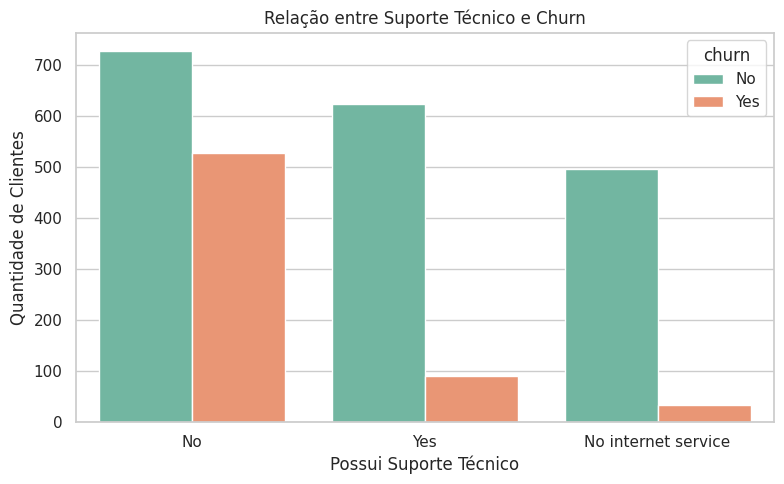

churn                   No    Yes
suporte_tecnico                  
No                   57.97  42.03
No internet service  93.94   6.06
Yes                  87.38  12.62


In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='suporte_tecnico', hue='churn', palette='Set2')

plt.title('Relação entre Suporte Técnico e Churn')
plt.xlabel('Possui Suporte Técnico')
plt.ylabel('Quantidade de Clientes')
plt.tight_layout()
plt.show()
# Cruzamento em percentual para ajudar na análise
crosstab = pd.crosstab(df['suporte_tecnico'], df['churn'], normalize='index') * 100
print(crosstab.round(2))


 *4. Suporte Técnico (suporte_tecnico vs churn)
Análise Estatística: Os clientes que optam por não contratar o serviço adicional de suporte técnico apresentam uma taxa de abandono drástica de 42,03%, valor que desaba para 12,62% entre os que possuem o suporte.**

*Insight Estratégico: Cruzando este dado com os altos cancelamentos na fibra óptica, conclui-se que grande parte dos clientes adquire serviços complexos mas fica desamparada tecnicamente. Fortalecer a oferta de suporte técnico e integrá-lo melhor na jornada do usuário de fibra pode ser a chave para reduzir drasticamente as perdas**

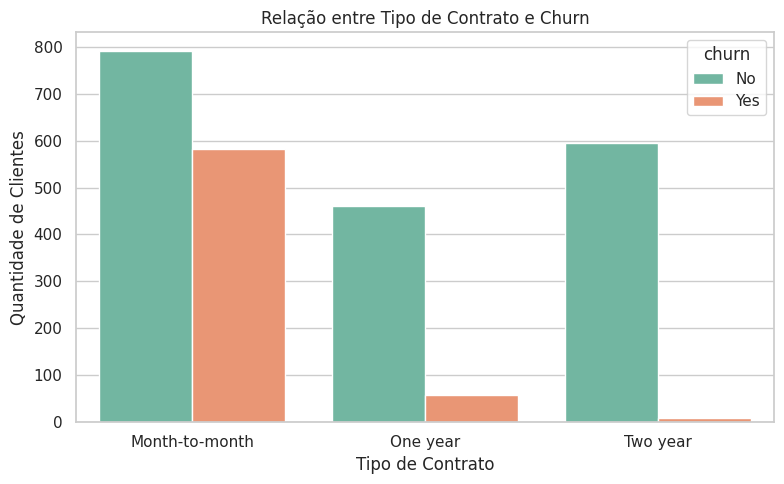

churn              No    Yes
tipo_contrato               
Month-to-month  57.61  42.39
One year        88.80  11.20
Two year        98.51   1.49


In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='tipo_contrato', hue='churn', palette='Set2')
plt.title('Relação entre Tipo de Contrato e Churn')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.tight_layout()
plt.show()
# Percentuais exatos para apoiar a nossa análise
crosstab = pd.crosstab(df['tipo_contrato'], df['churn'], normalize='index') * 100
print(crosstab.round(2))

*5. Tipo de Contrato (tipo_contrato vs churn)
Análise Estatística: Os dados revelam que os clientes com contratos mensais (Month-to-month) concentram a esmagadora maioria dos cancelamentos, apresentando uma taxa de churn alarmante de 42,39%. Em contrapartida, os contratos de um ano caem para 11,20% e os de dois anos reduzem o abandono para apenas 1,49%.**

*Insight Estratégico: A modalidade de contrato mensal expõe a operadora a uma alta volatilidade da base. Recomenda-se uma ação conjunta com o Marketing para criar campanhas de incentivo à migração (como descontos progressivos ou benefícios exclusivos) e com as Vendas para repensar a estratégia de captação focada em fidelizações de longo prazo.**